On a un pb de régression

modèles à essayer : régression linéaire, KNN, forets aléatoires, xgboost, réseaux de neuronnes
(notamment des RNN car séries temporelles)

mélangent de modèles ? 


QUESTIONNEMENT : 

- prédire les deux sorties à la fois ou les deux séparément ?
La question se pose surtout
pour les réseaux de neuronnes : des études ont montré que dans certains cas (je me rappelle plus lesquels)
cela améliore la performance car cela oblige le réseau de neuronnes à comprendre dans la profondeur les
données

- Quel retard choisir ?? 
Peut être choisir par validation croisée ? 

- peu de données ... 1000 observations --> attention au surapprentissage 








On importe les modules et packages nécessaires pour le on fonctionnement du code (peut être faire un 
requirements.txt puis pip install -r requirements.txt)

In [1]:
#%pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

chargement des données et première exploration des données

['Utr', 'Ytr', 'Uts1', 'Uts2']
Utr shape: (1000, 2)
Ytr shape: (1000, 2)
Uts shape: (1000, 2)
Uts2 shape: (1000, 2)
       Utr0      Utr1
0  1.225856  0.043213
1 -0.379083 -0.411898
2  0.683140 -0.921644
3  0.374853 -0.572683
4  0.256665 -0.760764
       Ytr0      Ytr1
0  0.000000  0.000000
1  0.042170  0.720120
2 -0.016521 -0.222306
3 -0.235810  0.020866
4 -0.080339 -0.352666


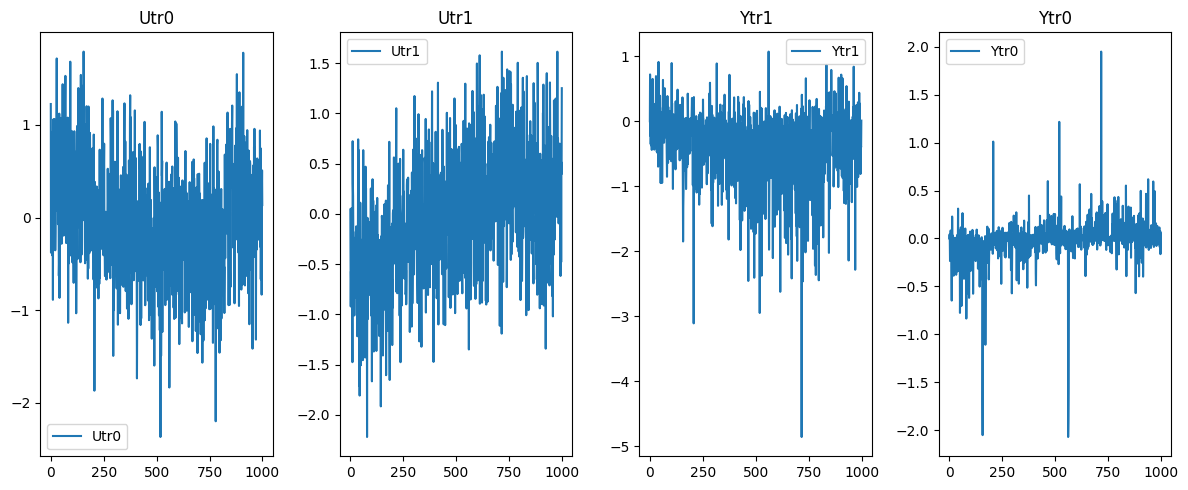

In [3]:
# Charger le fichier
data = np.load('StudentdataNARX.npz')

# Voir la liste des variables
print(data.files)

Utr = data['Utr']
Ytr = data['Ytr']
Uts = data['Uts1']
Uts2 = data['Uts2']

print("Utr shape:", Utr.shape)
print("Ytr shape:", Ytr.shape)
print("Uts shape:", Uts.shape)
print("Uts2 shape:", Uts2.shape)



# transformer les données de train en dataframe pandas
X = pd.DataFrame(Utr, columns=[f'Utr{i}' for i in range(Utr.shape[1])])
Y = pd.DataFrame(Ytr, columns=[f'Ytr{i}' for i in range(Ytr.shape[1])])
print(X.head(5))
print(Y.head(5))



figure, axes = plt.subplots(1, 4, figsize=(12, 5))
axes[0].plot(X['Utr0'], label='Utr0')
axes[0].set_title('Utr0')
axes[0].legend()
axes[1].plot(X['Utr1'], label='Utr1')
axes[1].set_title('Utr1')
axes[1].legend()
axes[2].plot(Y['Ytr1'], label='Ytr1')
axes[2].set_title('Ytr1')
axes[2].legend()
axes[3].plot(Y['Ytr0'], label='Ytr0')
axes[3].set_title('Ytr0')
axes[3].legend()
plt.tight_layout()
plt.show()


- Création des pilotes

PILOTE NARX1

          u
0  0.000000
1  0.993428
2 -0.276529
3  1.295377
4  3.046060
shape U (1001, 1)
         y1        y2
0  1.043227  0.462317
1  0.475838  0.739251
2  1.552033  1.121134
3  1.634857  1.814404
4  2.444431  2.115560
5  3.334967  1.464612
6  2.949286  0.591795
7  2.017657  2.589248
8  1.442401  2.441482
9  2.239213  2.024891
shape Y (1000, 2)
shape U (1000, 1)


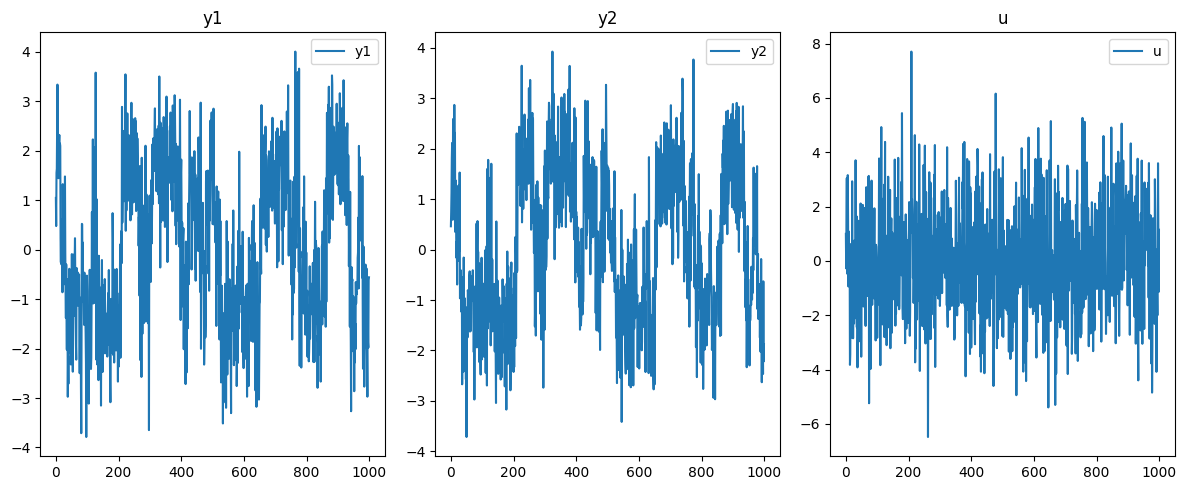

In [7]:

#simule NARX1 en pouvant choisir longueur (N) et variance du bruit
# dois etre mis en fonction car demande d'être flexible 
def simulate_Narx1(n_points,sigma_noise,seed=42): 

    np.random.seed(seed) # pour la reproductibilité
    
    # création des pilotes donnés dans l'énoncé
    # génération de U
    U_Narx1 = pd.DataFrame(np.zeros((n_points+1,1)),columns=['u']) #permet d'ajouter instant zéro pour y(0)=u(0)=0
    Y_Narx1 = pd.DataFrame(np.zeros((n_points+1,2)),columns=['y1', 'y2'])
   
    # générer U qui suit une distribution normale (moyenne 0, écart-type 2) : mon choix arbitraire
    U_Narx1.loc[1:,'u'] = np.random.normal(0, 2, size=n_points) #évite 4 lignes en plus
    # n+1 points car on a u-1 qui doit être défini pour générer y1_1 et y2_1 :
    # on change sa valeur en 0 après
    #U_Narx1.loc[0, 'u'] = 0 # pour respecter l'énoncé =u-1 = 0
    #U_Narx1.loc[1, 'u'] = 0 # u0 = 0

    print(U_Narx1.head())
    print("shape U", U_Narx1.shape)


    # génération de Y
    # y1_0 = 0, y2_0 = 0 # cf énoncé : je me mets dans le m^me cas que les données réelles
    # à prédire (exo principal du projet)
    y1_0 = 0
    y2_0 = 0
    # y-1 = 0, y-2 = 0 # cf énoncé, nécessaire pour générer y1_1 et y2_1
    y1_minus_1 = 0
    y2_minus_1 = 0
    Y_Narx1.loc[0] = [y1_minus_1, y2_minus_1]
    Y_Narx1.loc[1] = [y1_0, y2_0]

    for i in range(1, n_points+1): # on est décalé à 2 car on a ajouter y-1
        
        # les indices seront réglés après la boucle
        y1_k1= Y_Narx1['y1'].iloc[i-2] if i-2>=0 else 0 #car iloc def de 0 à length-1 donc quand -1 pas bon 
        y2_k1= Y_Narx1['y2'].iloc[i-2] if i-2>=0 else 0
        u_k1=U_Narx1['u'].iloc[i-2] if i-2>=0 else 0

        # deux formules données dans l'énoncé
        y1_i = 0.5 * y2_k1 + np.sin(Y_Narx1['y2'].iloc[i-1]) + 0.3 * u_k1 + np.random.normal(loc=0, scale=sigma_noise)
        y2_i = 0.5 * y1_k1 + np.sin(Y_Narx1['y1'].iloc[i-1]) + 0.2 * U_Narx1['u'].iloc[i-1] + np.random.normal(loc=0, scale=sigma_noise)
        Y_Narx1.loc[i] = [y1_i, y2_i]

    # enlever la première ligne qui correspond à y-1 et u-1et qui ont servi à générer les données
    Y_Narx1 = Y_Narx1.drop(index=0).reset_index(drop=True)
    U_Narx1 = U_Narx1.drop(index=0).reset_index(drop=True)

    return U_Narx1, Y_Narx1

n_points=1000
sigma=0.5
U_Narx1, Y_Narx1 = simulate_Narx1(n_points,sigma)

print(Y_Narx1.head(10))
print("shape Y", Y_Narx1.shape)
print("shape U", U_Narx1.shape)


# visualiser les données générées
figure, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].plot(Y_Narx1['y1'], label='y1')
axes[0].set_title('y1')
axes[0].legend()
axes[1].plot(Y_Narx1['y2'], label='y2')
axes[1].set_title('y2')
axes[1].legend()
axes[2].plot(U_Narx1['u'], label='u')
axes[2].set_title('u')
axes[2].legend()
plt.tight_layout()
plt.show()


PILOTE NARX2

         u1        u2
0  0.000000  0.000000
1  0.000000  0.000000
2  0.064769 -0.064694
3  0.152303  0.069822
4 -0.023415  0.039349
shape U (1001, 2)
          y1        y2
0   0.000000  0.000000
1  -0.080542  0.058610
2   0.031950  0.156569
3   0.039238 -0.039606
4   0.100274 -0.004496
5   0.029741  0.142264
6   0.089399  0.057062
7  -0.035896 -0.050313
8   0.123420  0.013685
9   0.032402 -0.070699
10  0.208165 -0.040266
11 -0.041501 -0.002366
12  0.112046 -0.179520
13  0.055902 -0.140280
14 -0.058909 -0.065280
shape Y (1000, 2)
shape U (1000, 2)


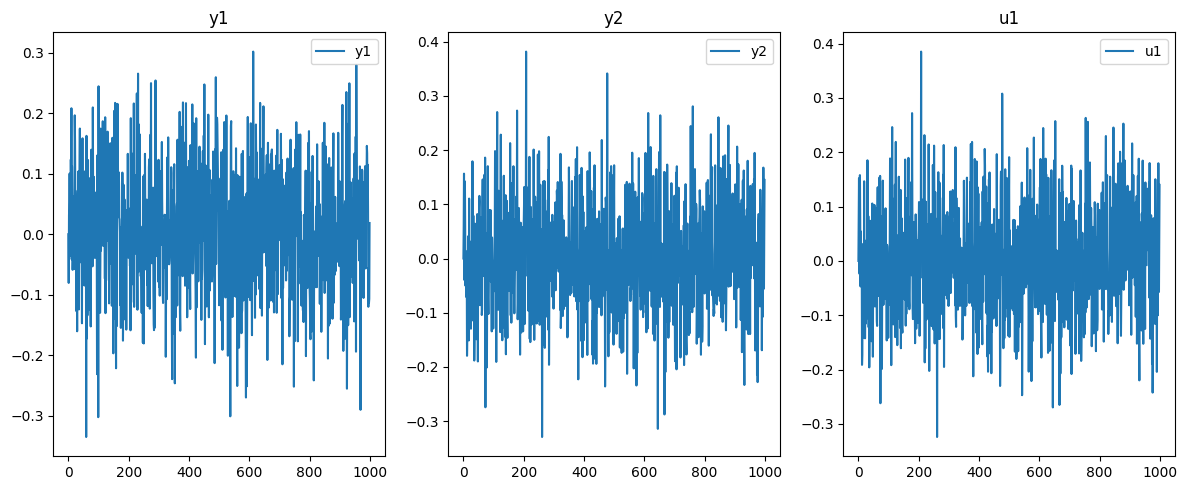

In [5]:
np.random.seed(42) # pour la reproductibilité

# génération de U (deux colonnes cette fois ci u1 et u2)
U_Narx2 = pd.DataFrame(columns=['u1', 'u2'])
Y_Narx2 = pd.DataFrame(columns=['y1', 'y2'])
# générer U qui suit une distribution normale (moyenne 0, écart-type 0.1) : mon choix
# arbitraire. Pour le coupp si je mets une trop grand evariance il y a explosion des données
U_Narx2['u1'] = np.random.normal(0, 0.1, size=n_points+1)
U_Narx2['u2'] = np.random.normal(0, 0.1, size=n_points+1)
# n+1 points car on a u-1 qui doit être défini pour générer y1_1 et y2_1 :
# on change sa valeur en 0 après
# pa rapport à la génération de Y, pas besoin de remonter à u-2 (cf formules)
U_Narx2.loc[0, 'u1'] = 0 # pour respecter l'énoncé =u-1 = 0
U_Narx2.loc[1, 'u1'] = 0 # u0 = 0
U_Narx2.loc[0, 'u2'] = 0 # pour respecter l'énoncé =u-1 = 0
U_Narx2.loc[1, 'u2'] = 0 # u0 = 0

print(U_Narx2.head())
print("shape U", U_Narx2.shape)


# génération de Y
# y1_0 = 0, y2_0 = 0 # cf énoncé : je me mets dans le m^me cas que les données réelles
# à prédire (exo principal du projet)
y1_0 = 0
y2_0 = 0
# y-1 = 0, y-2 = 0 # cf énoncé, nécessaire pour générer y1_1 et y2_1
y1_minus_1 = 0
y2_minus_1 = 0
y1_minus_2 = 0
y2_minus_2 = 0
Y_Narx2.loc[0] = [y1_minus_2, y2_minus_2]
Y_Narx2.loc[1] = [y1_minus_1, y2_minus_1]
Y_Narx2.loc[2] = [y1_0, y2_0]
# Bien faire attention à supprimer les 2 lignes à la fin et pas une seule
# il faudra peut être les rajouter pour nos stratégies dans le futur (dépend de à quel point on souhaite
# regarder le futur)


for k in range(2, n_points+1): # on est décalé à 2 car on a ajouter y-1
    # les indices seront réglés après la boucle
    # deux formules données dans l'énoncé

    y1_k = Y_Narx2.loc[k, 'y1']
    y1_km1 = Y_Narx2.loc[k-1, 'y1']
    y1_km2 = Y_Narx2.loc[k-2, 'y1']

    y2_k = Y_Narx2.loc[k, 'y2']
    y2_km1 = Y_Narx2.loc[k-1, 'y2']
    y2_km2 = Y_Narx2.loc[k-2, 'y2']

    u1_k = U_Narx2.loc[k, 'u1']
    u1_km1 = U_Narx2.loc[k-1, 'u1']

    u2_k = U_Narx2.loc[k, 'u2']
    u2_km1 = U_Narx2.loc[k-1, 'u2']

    # Génération du bruit blanc w
    w1 = np.random.normal(0, 0.02)
    w2 = np.random.normal(0, 0.02)

    # Formule pour y1(k+1)
    num1 = y1_k * y1_km1 * y1_km2 * (y1_km2 - 1) * u2_km1 + u2_k
    den1 = 1 + y2_km1**2 + y2_km2**2
    y1_plus1 = (num1 / den1) + w1

    # Formule pour y2(k+1)
    num2 = y2_k * y2_km1 * y2_km2 * (y2_km2 - 1) * u1_km1 + u1_k
    den2 = 1 + y1_km1**2 + y1_km2**2
    y2_plus1 = (num2 / den2) + w2

    # Stockage du résultat à l'indice k+1
    Y_Narx2.loc[k+1] = [y1_plus1, y2_plus1]

# enlever la première ligne qui correspond à y-1 et y-2 et u-1 qui ont servi à générer les données
Y_Narx2 = Y_Narx2.drop(index=1).reset_index(drop=True)
Y_Narx2 = Y_Narx2.drop(index=0).reset_index(drop=True)
U_Narx2 = U_Narx2.drop(index=0).reset_index(drop=True)

print(Y_Narx2.head(15))
print("shape Y", Y_Narx2.shape)
print("shape U", U_Narx2.shape)

# visualiser les données générées
figure, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].plot(Y_Narx2['y1'], label='y1')
axes[0].set_title('y1')
axes[0].legend()
axes[1].plot(Y_Narx2['y2'], label='y2')
axes[1].set_title('y2')
axes[1].legend()
axes[2].plot(U_Narx2['u1'], label='u1')
axes[2].set_title('u1')
axes[2].legend()
plt.tight_layout()
plt.show()


On a des données très très bruitées .... Utiliser des pilotes très bruités

- Test de nos pilotes : en connaissant la formule de génération qui est linéaire pour Narx1
De plus, pour NArx1, le modèle est linéaire en ses coefficients

On prépare déjà les dataframes, et les jeux de données de tests et train. 
C'est une question qui peut être intéressante à discuter : comment séparer les trains tests ...
J'ai codé 2 méthodes pour faire ça : 
1 méthode qui sépare chronoogiquement les données et une autre qui sépare de manière alternée (peut être plus judicieux poir avoir pls échantillons de val)



In [506]:
# regression linéaire sur NArx1
U_Narx1_reg = pd.DataFrame()
U_Narx1_reg['u'] = U_Narx1['u']
U_Narx1_reg['u_lag1'] = U_Narx1['u'].shift(1) # décalge vers le bas
U_Narx1_reg['u_lag2'] = U_Narx1['u'].shift(2)
U_Narx1_reg['y1_lag1'] = Y_Narx1['y1'].shift(1)
U_Narx1_reg['y1_lag2'] = Y_Narx1['y1'].shift(2)
U_Narx1_reg['y2_lag1'] = Y_Narx1['y2'].shift(1)
U_Narx1_reg['y2_lag2'] = Y_Narx1['y2'].shift(2)
# cf énoncé, les conditions initiales avant l'instant 0 sont nulles

U_Narx1_reg = U_Narx1_reg.fillna(0)

print(U_Narx1_reg.head())
print(Y_Narx1.head())
print("shape U", U_Narx1_reg.shape)


Y_Narx1_reg = pd.DataFrame()
Y_Narx1_reg['y1'] = Y_Narx1['y1'].shift(-1)  # décalage vers le haut pour faire correspondre
Y_Narx1_reg['y2'] = Y_Narx1['y2'].shift(-1) # y1(k+1) avec la bonne ligne de feautures
# afficher la fin du dataframe pour vérifier que le décalage a fonctionné
print(Y_Narx1_reg.tail())
print("shape Y", Y_Narx1_reg.shape)
# dernière ligne de Y est des NA car on a décalé vers le haut, on la supprime car on ne peut
# pas faire de prédiction pour cette ligne. On l'enelve aussi dans U pour garder les mêmes dimensions
Y_Narx1_reg = Y_Narx1_reg.drop(index=Y_Narx1_reg.index[-1]).reset_index(drop=True)
U_Narx1_reg = U_Narx1_reg.drop(index=U_Narx1_reg.index[-1]).reset_index(drop=True)

print(Y_Narx1_reg.tail())
print("shape final Y", Y_Narx1_reg.shape)
print("shape final U", U_Narx1_reg.shape)

# séparation des données en train et test

def split_train_val(X, Y, methode="chronologique", val_size=0.2, train_size_alt=50, val_size_alt=10):
    """
    Split les données en train et val selon la méthode choisie.
    - méthode chronologique : les données de train sont les premières lignes du dataframe, les données de val sont les dernières lignes du dataframe
    - méthode alternée : les données de train et de val sont alternées dans le dataframe, on choisit le nombre de samples de val que l'on veut (ex : 5)
    """
    if methode == "chronologique":
        n_train = int(len(X) * (1 - val_size))
        X_train = X.iloc[:n_train]
        Y_train = Y.iloc[:n_train]
        X_val = X.iloc[n_train:]
        Y_val = Y.iloc[n_train:]

    elif methode == "alternee":
        X_train = []
        Y_train = []
        X_val = []
        Y_val = []
        i = 0
        verif_nb_samples = train_size_alt + val_size_alt # pour avoir des blocs complets de train et val
        while verif_nb_samples <= len(X):
            X_train.append(X.iloc[i:i+train_size_alt])
            Y_train.append(Y.iloc[i:i+train_size_alt])
            X_val.append(X.iloc[i+train_size_alt:i+train_size_alt+val_size_alt])
            Y_val.append(Y.iloc[i+train_size_alt:i+train_size_alt+val_size_alt])
            i += train_size_alt + val_size_alt
            verif_nb_samples += train_size_alt + val_size_alt

    return X_train, Y_train, X_val, Y_val

print("split chronologique")
X_train_chrono, Y_train_chrono, X_val_chrono, Y_val_chrono = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="chronologique", val_size=0.2)
print("Shape : ", X_train_chrono.shape, Y_train_chrono.shape, X_val_chrono.shape, Y_val_chrono.shape)
print("split alterné")
X_train_alterne, Y_train_alterne, X_val_alterne, Y_val_alterne = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="alternee", train_size_alt=50, val_size_alt=10)
print("Shape : ", X_train_alterne[-1].shape, Y_train_alterne[-1].shape, X_val_alterne[-1].shape, Y_val_alterne[-1].shape)

          u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1  1.295377  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
2  3.046060  1.295377  0.000000  0.462317  0.000000  0.029815  0.000000
3 -0.468307  3.046060  1.295377 -0.293658  0.462317  1.054210  0.029815
4 -0.468274 -0.468307  3.046060  1.469774 -0.293658  0.998512  1.054210
         y1        y2
0  0.000000  0.000000
1  0.462317  0.029815
2 -0.293658  1.054210
3  1.469774  0.998512
4  2.599175  1.279188
shape U (1000, 7)
           y1        y2
995 -2.189251 -0.775566
996 -0.479401 -1.260986
997 -0.916928 -1.655468
998 -2.590498 -0.637316
999       NaN       NaN
shape Y (1000, 2)
           y1        y2
994 -0.453176 -1.503575
995 -2.189251 -0.775566
996 -0.479401 -1.260986
997 -0.916928 -1.655468
998 -2.590498 -0.637316
shape final Y (999, 2)
shape final U (999, 7)
split chronologique
Shape :  (799, 7) (799, 2) (200, 7) (200, 2)
s

- Travail rapide, pas spécialement important, donne une brève idée 

- Analyse en vif, très vif sur les vrais données

In [507]:
# calculer la corrélation entre les différentes variables
df_total = pd.concat([X], axis=1)
correlation_matrix_total = df_total.corr()
print("Correlation matrix:\n", correlation_matrix_total)

Correlation matrix:
                Utr0      Utr1  Utr0_lag1  Utr1_lag1  Ytr0_lag1  Ytr1_lag1  \
Utr0       1.000000 -0.054575   0.164379  -0.031550  -0.006342   0.053255   
Utr1      -0.054575  1.000000  -0.007804   0.163169  -0.017272  -0.037318   
Utr0_lag1  0.164379 -0.007804   1.000000  -0.057769   0.026686   0.107188   
Utr1_lag1 -0.031550  0.163169  -0.057769   1.000000   0.068883  -0.093600   
Ytr0_lag1 -0.006342 -0.017272   0.026686   0.068883   1.000000  -0.345968   
Ytr1_lag1  0.053255 -0.037318   0.107188  -0.093600  -0.345968   1.000000   
Utr0_lag2  0.129076 -0.048258   0.164458  -0.011911  -0.093912   0.686487   
Utr1_lag2 -0.015206  0.037064  -0.033296   0.164686   0.407920  -0.426670   
Ytr0_lag2 -0.044521  0.006152  -0.006115  -0.017837   0.314061   0.239534   
Ytr1_lag2  0.081833 -0.026243   0.054619  -0.040370  -0.033362  -0.186157   
Utr0_lag3  0.118065 -0.044927   0.128556  -0.049798   0.041577  -0.067909   
Utr1_lag3 -0.058470  0.021074  -0.018330   0.040550   0

Les coefficients ne sont pas si élevés que ca ... la régression linéaire sur ces variables explicatives semblent compromis

- REGRESSION LINEAIRE 

On va d'abord faire une régression linéaire en utilisant simplement les valeurs de u1 et u2 pour prédire y. On s'attend cependant à des résultats plutôt moyen 

In [508]:
X_val = X[800:1000]
Y_val = Y[800:1000]
X_train = X[:800]
Y_train = Y[:800]

model = LinearRegression()
model.fit(X_train, Y_train["Ytr0"])
Y_pred = model.predict(X_val)
mse = mean_squared_error(Y_val["Ytr0"], Y_pred)
print("Mean Squared Error:", mse)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# erreur si on prédit la valeur moyenne de Ytr0
mean_prediction = np.mean(Y_train["Ytr0"])
mean_mse = mean_squared_error(Y_val["Ytr0"], [mean_prediction] * len(Y_val))
print("Mean Prediction MSE:", mean_mse)


# affichage des résultats
plt.figure(figsize=(10, 6))
plt.plot(Y_val["Ytr0"].values, label='True Values', marker='o')
plt.plot(Y_pred, label='Predicted Values', marker='x')
plt.title('True vs Predicted Values for Ytr0')
plt.xlabel('Sample Index')
plt.ylabel('Ytr0 Value')
plt.legend()
plt.grid()
plt.show()

ValueError: Found array with 0 sample(s) (shape=(0, 14)) while a minimum of 1 is required by LinearRegression.

On voit bien en comparant le mse d'un modèle qui prédit la moyenne de Ytr0 que le modèle 
de régression linéaire uniquement sur l'instant t

In [ ]:
X["Utr0_lag1"] = X["Utr0"].shift(1)
X["Utr1_lag1"] = X["Utr1"].shift(1)
X["Ytr0_lag1"] = Y["Ytr0"].shift(1)
X["Ytr1_lag1"] = Y["Ytr1"].shift(1)
X["Utr0_lag2"] = X["Utr0"].shift(2)
X["Utr1_lag2"] = X["Utr1"].shift(2)
X["Ytr0_lag2"] = Y["Ytr0"].shift(2)
X["Ytr1_lag2"] = Y["Ytr1"].shift(2)
X["Utr0_lag3"] = X["Utr0"].shift(3)
X["Utr1_lag3"] = X["Utr1"].shift(3)
X["Ytr0_lag3"] = Y["Ytr0"].shift(3)
X["Ytr1_lag3"] = Y["Ytr1"].shift(3)
X = X.dropna()
Y = Y.loc[X.index] # le dropna a supprimé les 3 premières lignes et n'a pas modifié les index
X_val = X[800:1000]
Y_val = Y[800:1000]
X_train = X[:800]
Y_train = Y[:800]
model = LinearRegression()
model.fit(X_train, Y_train["Ytr0"])
Y_pred = model.predict(X_val)
mse = mean_squared_error(Y_val["Ytr0"], Y_pred)
print("Mean Squared Error with lags:", mse)


ValueError: Found array with 0 sample(s) (shape=(0, 14)) while a minimum of 1 is required by LinearRegression.

Le problème c'est que là je connais le futur donc j'utilise les données réelles pour yk-1, etc et non les données prédites ... Cela evite l'effet boule de neige mais ce ne sera pas le cas en vrai ...

In [ ]:
# utiliser sa propre prédiction comme entrée pour les prédictions futures
Y_pred_future = []
current_input = X_val.iloc[0].copy() # copy pour ne pas modifier X_val
for i in range(len(X_val)):
    pred = model.predict(current_input.values.reshape(1, -1))[0]
    Y_pred_future.append(pred)
    current_input["Ytr0_lag1"] = pred
    current_input["Ytr0_lag2"] = current_input["Ytr0_lag1"]
    current_input["Ytr0_lag3"] = current_input["Ytr0_lag2"]
    current_input["Utr0_lag1"] = current_input["Utr0"]
    current_input["Utr1_lag1"] = current_input["Utr1"]
    current_input["Utr0_lag2"] = current_input["Utr0_lag1"]
    current_input["Utr1_lag2"] = current_input["Utr1_lag1"]
    current_input["Utr0_lag3"] = current_input["Utr0_lag2"]
    current_input["Utr1_lag3"] = current_input["Utr1_lag2"]
mse_future = mean_squared_error(Y_val["Ytr0"], Y_pred_future)
print("Mean Squared Error with future predictions:", mse_future)

Mean Squared Error with future predictions: 1.1655388334474992e-05


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
